#### DBSCAN Clustering

(i)     DBSCAN stands for Density based Spatial Cluetsring of Applications with Noise.

(ii)    It is one of the unsupervised machine learing technique.

(iii)   It is a clustering algorithm.

(iv)    It forms the clusters based on the density of the data points.


#### Main Idea behind DBSCAN Algorithm :----

(i) DBSCAN Algorithm forms the clusters by finding out the areas where the data points are very close with respect to each other.

(ii) The data points that are very far away from the others are considered as the noise / outliers.


#### Terminologies used:----

(a.)    epsilon (radius) ====>   It can be defined as the radius or the distance with which the circle is constructed around the core data point.

(b.)    Min samples  =========>  Minimum number of data points required to create a cluster is callled Min samples.

(c.)    Core Point  ==========>  It is a point around which a cluster is created.

(d.)    Border Point =========> It is a point near the core point inside the cluster is known as border point.

(e.)    Noise Point  =========> It is an isolated point which is very away from the rest of all the data points.


#### Step 1: Import all the necessary libraries



In [1135]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import train_test_split
from    sklearn.preprocessing       import StandardScaler, LabelEncoder
from    sklearn.neighbors	        import NearestNeighbors
from    sklearn.metrics             import silhouette_score
from    sklearn.cluster		        import DBSCAN

#### Step 2: Load the Dataset

In [1136]:
#### Load the dataset

df = pd.read_csv("Mall_Customers_dataset.csv")

In [1137]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains about the details of each and every customer with their "AnnualIncome" and their "SpendingScore".

#### Step 3: Perform the Data Exploration

In [1138]:
#### get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [1139]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [1140]:
#### get the first five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [1141]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [1142]:
#### get the columns used in the dataset

df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [1143]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [1144]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each numerical column used in the dataset.

In [1145]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe(include='object')

,Genre
count,200
unique,2
top,Female
freq,112


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each categorical column used in the dataset.

#### Step 4: Perform the Data Cleaning and Feature Engineering

In [1146]:
#### To rename the column names with their proper names

df.rename(columns={"Genre"                   :   "Gender"             ,
                    "Annual Income (k$)"     :   "Annual_Income"      ,
                    "Spending Score (1-100)" :   "Spending_Score"},
                    inplace=True)

In [1147]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  All the column names have been renamed with their proper names.

In [1148]:
#### To remove the un necessary column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [1149]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The CustomerID column has been removed from the dataset.

In [1150]:
#### To convert all the categorical columns of 'Gender' into the numerical values

from  sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

#### using the object for Label Encoder, transform the inputs

df['Gender'] = label.fit_transform(df['Gender'])

In [1151]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### OBSERVATIONS:

1.  All the categorical values of Gender column have been converted into their numerical values.

In [1152]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1153]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [1154]:
#### To get the correlation for all the numerical columns in the dataset

df.corr()

,Gender,Age,Annual_Income,Spending_Score
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual_Income,0.056410,-0.012398,1.000000,0.009903
Spending_Score,-0.058109,-0.327227,0.009903,1.000000


#### OBSERVATIONS:

1.  The above table depicts about the correlation between all the numerical columns used in the dataset.

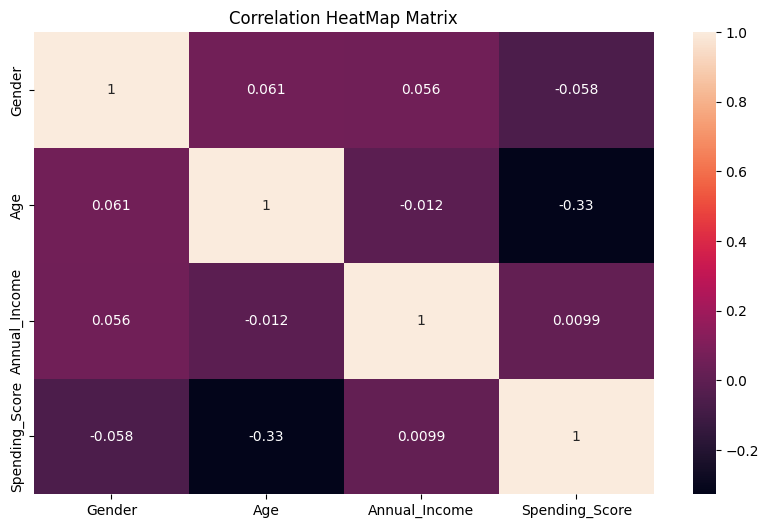

In [1155]:
#### To get the graphical representation for the correlation for all the numerical columns in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graphical representation depicts about the numerical correlation for all the column used in the dataset.

2.  The correlation between the 'Gender' and 'Age' is very high.

3.  The correlation between the 'Age' and 'Spending Score' is very low.

#### Step 6: Select Important Features

In [1156]:
#### Select all the important features

X = df[['Annual_Income','Spending_Score']]

In [1157]:
X

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


#### OBSERVATIONS:

1.  The features that were selected for performing the clustering operation in the dataset is 

    (a.)    Annual_Income

    (b.)    Spending_Score

#### Step 7: Perform the Feature Scaling on the selected features

In [1158]:
from sklearn.preprocessing import StandardScaler

##### create an object for StandardScaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

In [1159]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

#### OBSERVATIONS:

1.  Feature scaling standardizes all features to zero mean and unit variance.

2.  This prevents one feature from dominating due to larger scale.

#### Step 8: Find the optimal epsilon value or the radius using the KNN Method

Here we are using the KNN method to fing out the optimal value of epsilon

In [1160]:
from    sklearn.neighbors   import  NearestNeighbors

#### create an object for KNN 

knn = NearestNeighbors(n_neighbors=5)

#### OBSERVATIONS:

1.  Here we have created an object for KNN with total neighbors as 5 for each and every data points.

In [1161]:
#### using the object of knn, we are training the model

neighbors_fit = knn.fit(X_scaled)

In [1162]:
neighbors_fit

NearestNeighbors()

#### OBSERVATIONS:

1.  The object for knn model has been initialized.

2.  Using the object for knn, we have trained the  model with the help of the training data

3.  Then we have stored the trained data in neighnors_fit variable.

4.  This neighbors_fit learns all the patterns and features from the data as the model is completely trained under this.

In [1163]:
#### find out all the distances of each and every data point with respect to its neighbors

distances, indices = neighbors_fit.kneighbors(X_scaled)

In [1164]:
distances

array([[0.        , 0.08564307, 0.27669913, 0.37699224, 0.49391629],
       [0.        , 0.15990848, 0.20603662, 0.20857963, 0.24604156],
       [0.        , 0.07633886, 0.16332841, 0.31170347, 0.33100969],
       [0.        , 0.0544428 , 0.15267772, 0.15990848, 0.17128613],
       [0.        , 0.08564307, 0.24695814, 0.33025172, 0.48457129],
       [0.        , 0.0544428 , 0.12091014, 0.16332841, 0.17303595],
       [0.        , 0.07633886, 0.12255989, 0.26999162, 0.28226971],
       [0.        , 0.19782504, 0.24604156, 0.50013409, 0.51750782],
       [0.        , 0.12255989, 0.16332841, 0.24182028, 0.39008751],
       [0.        , 0.17303595, 0.19475561, 0.19782504, 0.22536634],
       [0.        , 0.0544428 , 0.0544428 , 0.31290921, 0.33100969],
       [0.        , 0.15753602, 0.19782504, 0.59950147, 0.60225816],
       [0.        , 0.0544428 , 0.07764312, 0.30781334, 0.35763644],
       [0.        , 0.07764312, 0.12091014, 0.15267772, 0.19782504],
       [0.        , 0.0544428 , 0.

#### OBSERVATIONS:

1.  As in KNN model, we have find out a total of 5 neighbors with respect to each data point.

2.  Then through the object of neighbors_fit, we have learnt all the patterns and features from the data
and found out distances of each data point with respect to its five neighbors.

In [1165]:
#### Selects all the distances of the fifth neighbors and sort them

sorted_distances = np.sort(distances[:,4],axis=0)

In [1166]:
sorted_distances

array([0.07633886, 0.07764312, 0.07764312, 0.07764312, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08651797,
       0.08651797, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.10888561, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.11450829, 0.11450829, 0.11450829, 0.11646468, 0.11646468,
       0.11646468, 0.11646468, 0.11646468, 0.12091014, 0.12091014,
       0.12091014, 0.12091014, 0.12255989, 0.12255989, 0.12255989,
       0.12255989, 0.12255989, 0.12255989, 0.13834957, 0.13834957,
       0.13834957, 0.13834957, 0.13834957, 0.13925388, 0.13925388,
       0.13925388, 0.13925388, 0.13925388, 0.15267772, 0.15267772,
       0.15267772, 0.15267772, 0.15528624, 0.15528624, 0.15528624,
       0.15753602, 0.15753602, 0.15753602, 0.15753602, 0.15753602,
       0.15753602, 0.15753602, 0.15753602, 0.15990848, 0.15990848,
       0.15990848, 0.16332841, 0.17128613, 0.17128613, 0.17303

#### OBSERVATIONS:

1.  Here we have obtained the distances of each and every data point with respect to the fifth neighbors in the ascending order.

#### Step 9: Plot K-Distance Graph

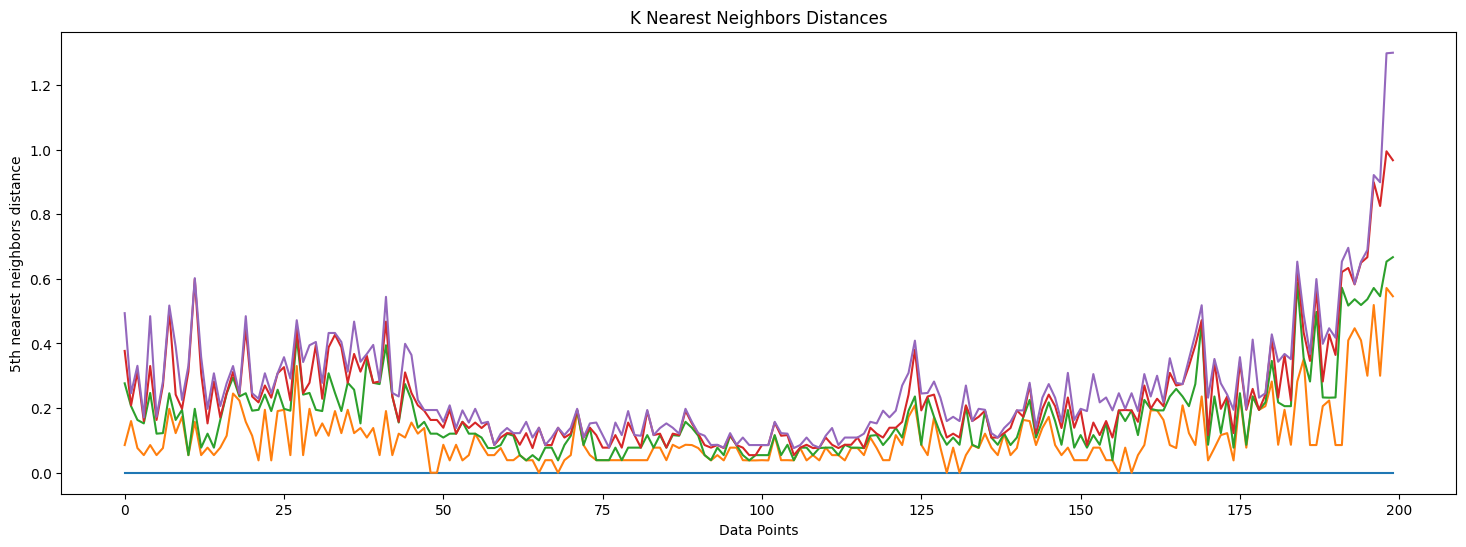

In [1167]:
plt.figure(figsize=(18,6))

plt.plot(distances)

plt.title("K Nearest Neighbors Distances")

plt.xlabel("Data Points")

plt.ylabel("5th nearest neighbors distance")

plt.show()

#### OBSERVATIONS:

1.  The above graph represents the distance of each and every data points with respect to the fifth neighbors.

#### Step 10:   Build the DBSCAN Model

In [1168]:
from sklearn.cluster import DBSCAN

In [1169]:
#### Create an object for DBSCAN

dbs = DBSCAN(
    eps                 =       0.5         ,
    min_samples         =       5
)

In [1170]:
#### using the object of DBSCAN, find the labels for the cluster

Y_pred_clusters = dbs.fit_predict(X_scaled)

In [1171]:
Y_pred_clusters

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1])

#### OBSERVATIONS:

1.  There are a total of three clusters formed from the above dataset

    (a.)    Cluster 0

    (b.)    Cluster 1

    (c.)    Cluster -1

#### Step 11: Add the Cluster Label to the dataset

In [1172]:
df['Cluster'] = Y_pred_clusters

In [1173]:
df.head()

,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,0
3,0,23,16,77,0
4,0,31,17,40,0


#### OBSERVATIONS:

1.  The cluster labels have been added into the dataset.

#### Step 12: Visualize Clusters

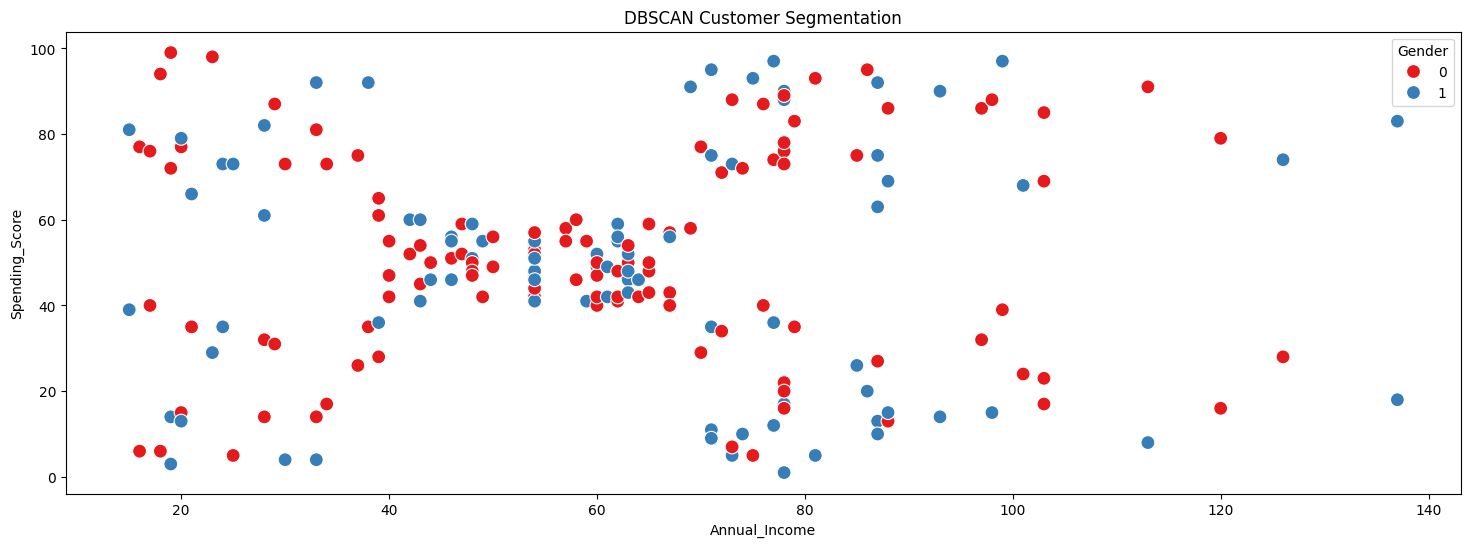

In [1174]:
plt.figure(figsize=(18,6))
sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'],hue=df['Gender'],palette='Set1',s=100)
plt.title("DBSCAN Customer Segmentation")
plt.show()

#### OBSERVATIONS:

1.  From the above graph, we have performed DBSCAN Clustering algorithm on the Mall_Customers dataset and concluded that

    (a.)    The Female Customers Annaul Income and Spending score i.e all the expenses are much higher than the Male Customers.

2.  


| Cluster | Meaning                        |
| ------- | ------------------------------ |
| 0       | Medium income, medium spending |
| 1       | High income, high spending     |
| 2       | Low income, low spending       |
| -1      | Outlier customers              |

3. From the above table we can see that

    (a.)    Cluster 0 ================>  medium annual income and medium spending score

    (b.)    Cluster 1 ================>  high annual income and high spending score

    (c.)    Cluster 2 ================>  low annual income and low spending score

    (d.)    Cluster -1 ===============> Outlier 

#### Step 13: #### Check the total number of clusters

In [1175]:
n_clusters = len(set(Y_pred_clusters))-(1 if -1 in Y_pred_clusters else 0)

print("Number of clusters is:", n_clusters)

Number of clusters is: 2


#### Step 14: Count the total number of noise points

In [1176]:
data = list(Y_pred_clusters)

In [1177]:
noise_points = data.count(-1)

In [1178]:
#### count the total number of noise points

print("Total number of noise points are:", noise_points)

Total number of noise points are: 8
